##Problem Statement :

Apple Stock Price Prediction for the Next 30 Days
The primary objective of this project is to develop a predictive model that forecasts Apple stock prices for the next 30 days using historical stock data from 2012 to 2019. The model will help investors, traders, and financial analysts make informed decisions based on stock trends and potential market movements.
________________________________________
Key Goals:

✅ Develop a time series forecasting model to predict Apple’s stock price for the next 30 days.
✅ Analyze short-term and long-term trends in stock prices.
✅ Explore the impact of external events (e.g., earnings reports, macroeconomic events, global financial crises) on Apple’s stock.
✅ Evaluate different machine learning models such as ARIMA, SARIMA, and XGBoost for accurate forecasting.
✅ Visualize trends, seasonality, and volatility in Apple’s stock prices.
✅ Deploy the final forecasting model using a Flask/Streamlit web app to allow real-time predictions.
________________________________________
Dataset & Attributes:

The dataset consists of daily stock market data for Apple from 2012 to 2019, including:
📌 Stock Market Indicators:
●	Date: Trading date
●	Open: Opening price of Apple stock for the day
●	High: Highest price reached during the day
●	Low: Lowest price reached during the day
●	Close: Closing price of Apple stock for the day
●	Volume: Number of shares traded on that day
📌 Target Variable:
●	Next 30-Day Close Price Forecast
----------------------------------------
Phase 1
________________________________________
Modeling Approach:
🔹 Data Preprocessing – Handling missing values, normalizing stock price data, and feature engineering (e.g., moving averages, volatility measures).
🔹 Exploratory Data Analysis (EDA) – Identifying trends, seasonality, and stock price patterns.
# ==========================
# 📌 Step 1: Upload CSV file
# ==========================



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df =pd.read_csv('P675 DATASET.csv')

In [2]:
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())

         Date       Open       High        Low      Close  Adj Close    Volume
0  2012-01-03  58.485714  58.928570  58.428570  58.747143  50.765709  75555200
1  2012-01-04  58.571430  59.240002  58.468571  59.062859  51.038536  65005500
2  2012-01-05  59.278572  59.792858  58.952858  59.718571  51.605175  67817400
3  2012-01-06  59.967144  60.392857  59.888573  60.342857  52.144630  79573200
4  2012-01-09  60.785713  61.107143  60.192856  60.247143  52.061932  98506100
(2011, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2011 entries, 0 to 2010
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2011 non-null   object 
 1   Open       2011 non-null   float64
 2   High       2011 non-null   float64
 3   Low        2011 non-null   float64
 4   Close      2011 non-null   float64
 5   Adj Close  2011 non-null   float64
 6 

In [3]:
#Statistical Summary before backfilling of weekend data
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2011.000000,2011.000000,2011.000000,2011.000000,2011.000000,2.011000e+03
mean,126.707469,127.827594,125.580258,126.741235,119.505548,5.949670e+07
std,50.483753,50.926301,50.124940,50.578369,52.438444,4.683856e+07
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07
25%,85.882858,86.717858,85.056427,86.202145,75.056679,2.758565e+07
50%,113.050003,114.190002,111.870003,113.050003,105.222908,4.346900e+07
75%,165.190002,167.409996,163.424995,165.245002,160.047111,7.471030e+07
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08


In [4]:
#Converting date to the right format and calculating month date and year as additional parameters
import datetime
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Day_of_Week'] = df['Date'].dt.dayofweek
df['Day'] = df['Date'].dt.day
print(df.dtypes)

Date           datetime64[ns]
Open                  float64
High                  float64
Low                   float64
Close                 float64
Adj Close             float64
Volume                  int64
Month                   int32
Year                    int32
Day_of_Week             int32
Day                     int32
dtype: object


In [5]:
#Sorting Dates
df = df.sort_values(by='Date')
df = df.reset_index(drop=True)

In [6]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Month,Year,Day_of_Week,Day
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,1,2012,1,3
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,1,2012,2,4
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,1,2012,3,5
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200,1,2012,4,6
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100,1,2012,0,9



# ==========================
# 📌 Step 2: EDA + Cleaning
# ==========================


In [7]:
#Checking For Null Values
df.isnull().sum()

Date           0
Open           0
High           0
Low            0
Close          0
Adj Close      0
Volume         0
Month          0
Year           0
Day_of_Week    0
Day            0
dtype: int64

In [8]:
#%Nullvalues
null_percentage = (df.isnull().sum() / len(df)) * 100
print(null_percentage)

Date           0.0
Open           0.0
High           0.0
Low            0.0
Close          0.0
Adj Close      0.0
Volume         0.0
Month          0.0
Year           0.0
Day_of_Week    0.0
Day            0.0
dtype: float64


In [9]:
#Checking for Duplicate value
df.duplicated().sum()

np.int64(0)

In [10]:
#Checking for Duplicate Dates
print(df['Date'].duplicated().sum())

0


In [11]:
#Setting Date to Index(Best Practice for Time Series Data)
df.set_index('Date', inplace=True)

In [12]:
df.head(3)

,Open,High,Low,Close,Adj Close,Volume,Month,Year,Day_of_Week,Day
Date,,,,,,,,,,
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200,1,2012,1,3
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500,1,2012,2,4
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400,1,2012,3,5


In [13]:
#Function to create sequence, setting the start and end parameters from the  DataFrame's index minimum and maximum values, and freq='D' to ensure daily intervals.
all_dates = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='D'
)

In [14]:
#Re-Indexing
df = df.reindex(all_dates)

In [15]:
#Checking for Dates with Missing values
missing_dates = df[df.isnull().any(axis=1)]
print(missing_dates)

            Open  High  Low  Close  Adj Close  Volume  Month  Year  \
2012-01-07   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2012-01-08   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2012-01-14   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2012-01-15   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2012-01-16   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
...          ...   ...  ...    ...        ...     ...    ...   ...   
2019-12-21   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2019-12-22   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2019-12-25   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2019-12-28   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   
2019-12-29   NaN   NaN  NaN    NaN        NaN     NaN    NaN   NaN   

            Day_of_Week  Day  
2012-01-07          NaN  NaN  
2012-01-08          NaN  NaN  
2012-01-14          NaN  NaN  
2012-01-15          NaN  NaN  
2012

In [16]:
#Forward Filling the missing data
df =df.ffill()

In [17]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Month,Year,Day_of_Week,Day
2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200.0,1.0,2012.0,1.0,3.0
2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500.0,1.0,2012.0,2.0,4.0
2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400.0,1.0,2012.0,3.0,5.0
2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200.0,1.0,2012.0,4.0,6.0
2012-01-07,59.967144,60.392857,59.888573,60.342857,52.144630,79573200.0,1.0,2012.0,4.0,6.0


In [18]:
#Statistical Summary after ff( No Significant change in data)
df.describe()

,Open,High,Low,Close,Adj Close,Volume,Month,Year,Day_of_Week,Day
count,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2.919000e+03,2919.000000,2919.000000,2919.000000,2919.000000
mean,126.648797,127.720562,125.516766,126.637198,119.409204,5.940383e+07,6.547105,2015.496745,2.604317,15.821172
std,50.491988,50.935133,50.124005,50.580143,52.440663,4.649637e+07,3.443427,2.290107,1.474479,8.785398
min,55.424286,57.085712,55.014286,55.790001,48.921928,1.136200e+07,1.000000,2012.000000,0.000000,1.000000
25%,85.882858,86.649998,84.914284,85.971428,74.883018,2.743215e+07,4.000000,2013.500000,1.000000,8.000000
50%,112.820000,114.209999,111.800003,113.050003,105.038940,4.394090e+07,7.000000,2015.000000,3.000000,16.000000
75%,165.415001,167.314995,163.630005,164.940002,159.646255,7.428530e+07,10.000000,2017.000000,4.000000,23.000000
max,291.119995,293.970001,288.119995,291.519989,289.522614,3.765300e+08,12.000000,2019.000000,4.000000,31.000000


In [19]:
#Checking Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2919 entries, 2012-01-03 to 2019-12-30
Freq: D
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Open         2919 non-null   float64
 1   High         2919 non-null   float64
 2   Low          2919 non-null   float64
 3   Close        2919 non-null   float64
 4   Adj Close    2919 non-null   float64
 5   Volume       2919 non-null   float64
 6   Month        2919 non-null   float64
 7   Year         2919 non-null   float64
 8   Day_of_Week  2919 non-null   float64
 9   Day          2919 non-null   float64
dtypes: float64(10)
memory usage: 250.9 KB


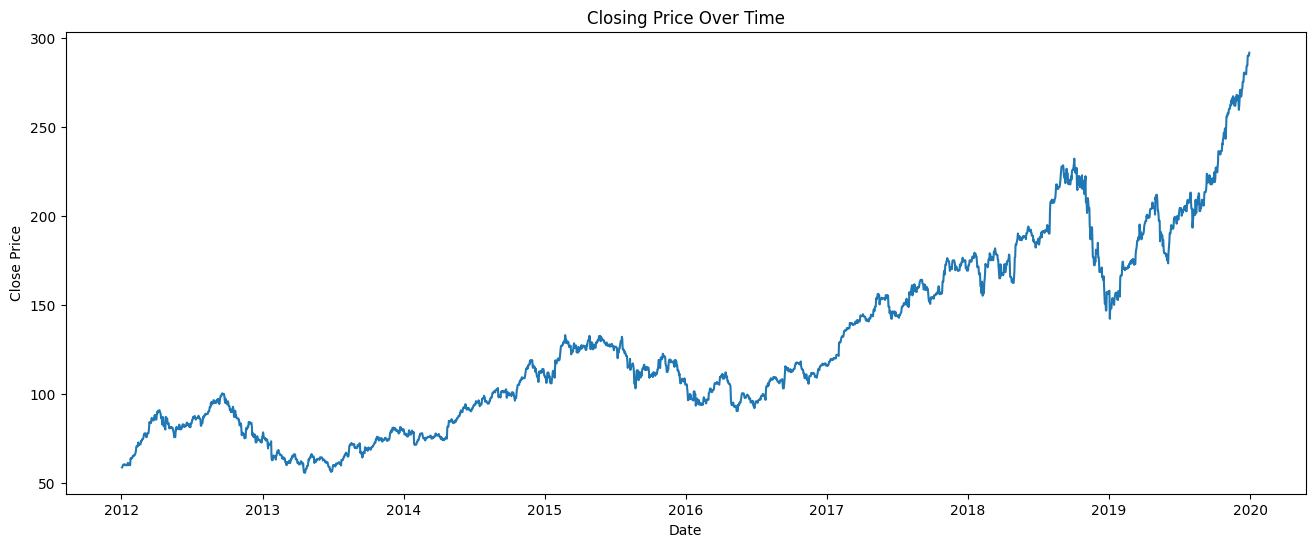

In [20]:
#Visualization for Closing Price
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
plt.plot(df.index, df['Close'])
plt.title('Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

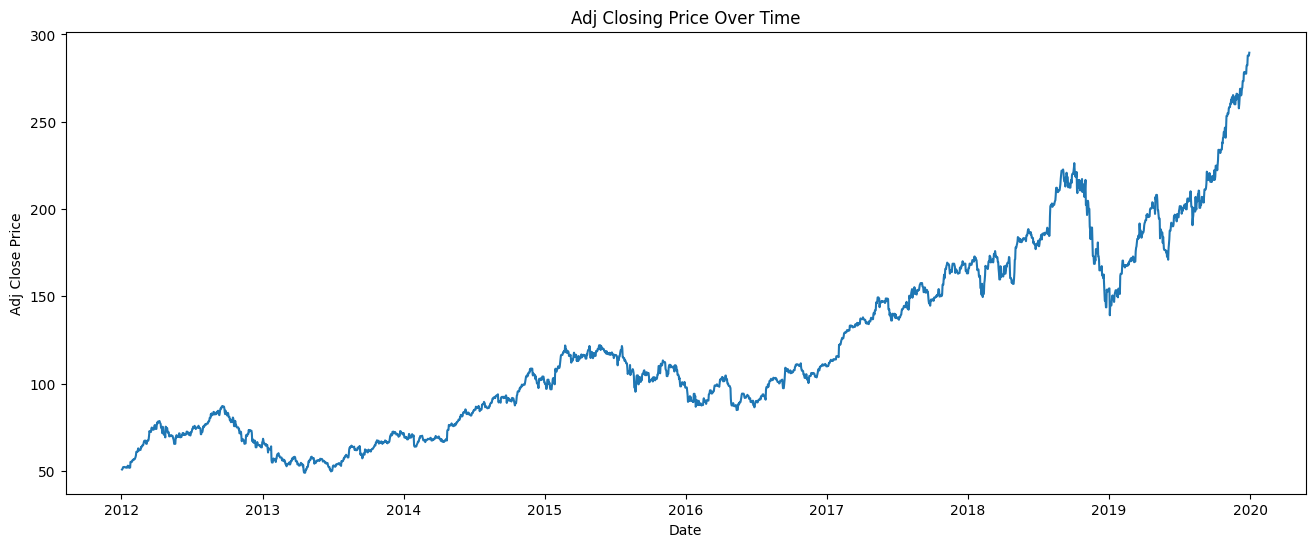

In [21]:
#Visualization for Adjusted Closing Price
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
plt.plot(df.index, df['Adj Close'])
plt.title('Adj Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adj Close Price')
plt.show()

In [22]:
#Difference Between Closing and Adjusted Closing Price
Adj_Close = df['Adj Close']
Close = df['Close']
df['diff'] = Adj_Close - Close

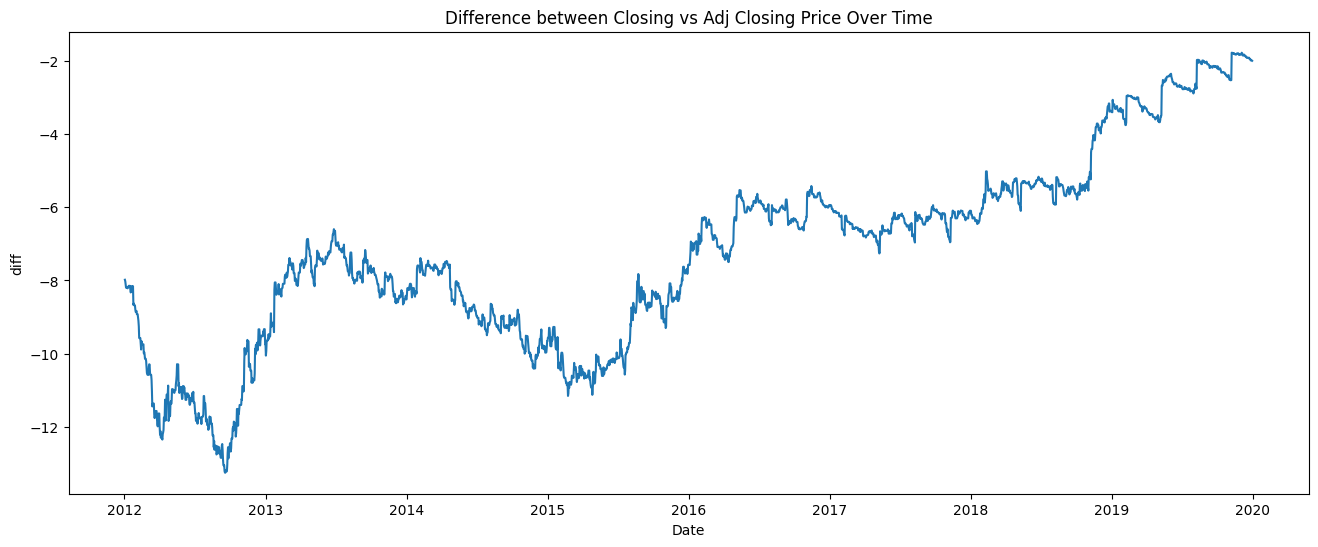

In [23]:
#Visualization for Adjusted Closing Price
import matplotlib.pyplot as plt
plt.figure(figsize=(16,6))
plt.plot(df.index, df['diff'])
plt.title('Difference between Closing vs Adj Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('diff')
plt.show()

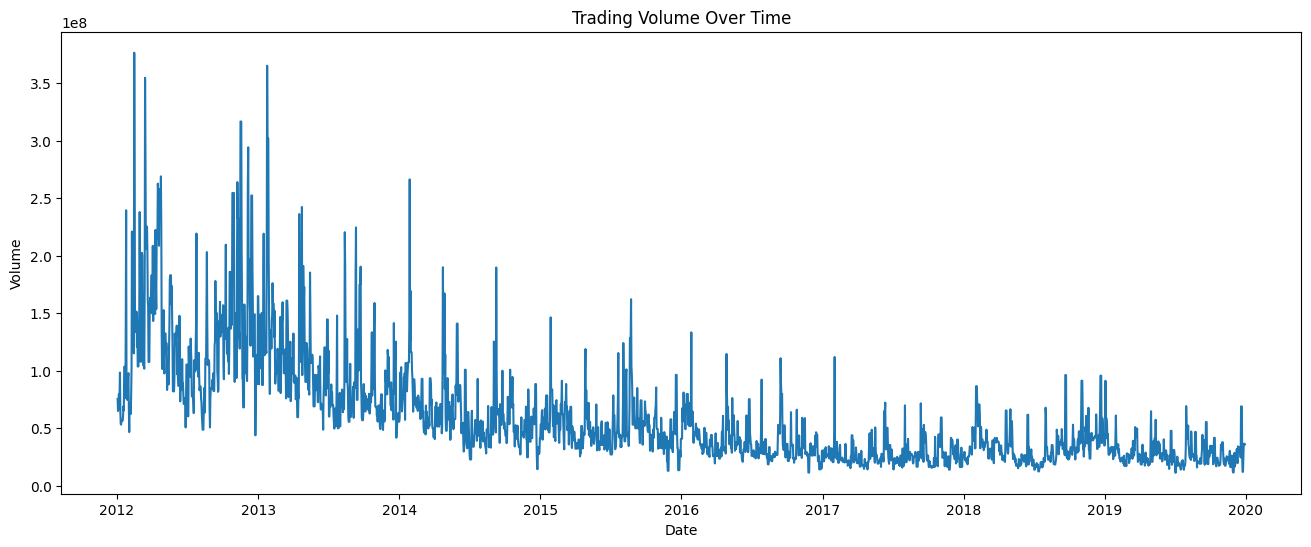

In [24]:
#Volume Analysis
plt.figure(figsize=(16,6))
plt.plot(df.index, df['Volume'])
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

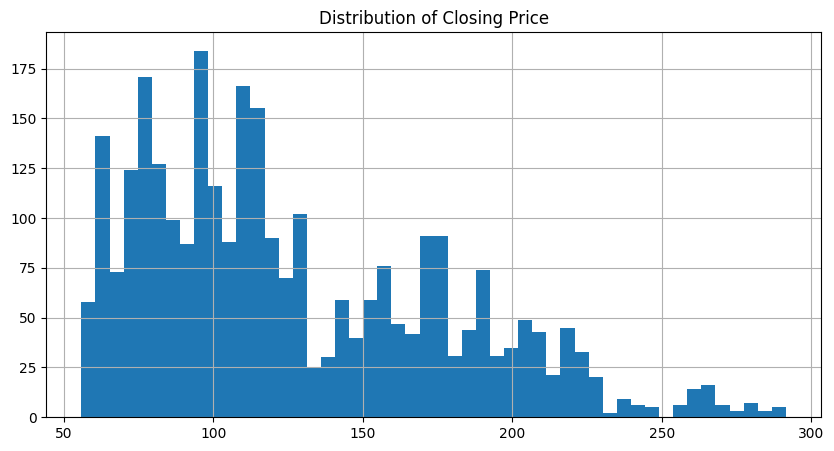

In [25]:
#Distribution Plot
df['Close'].hist(bins=50, figsize=(10,5))
plt.title("Distribution of Closing Price")
plt.show()

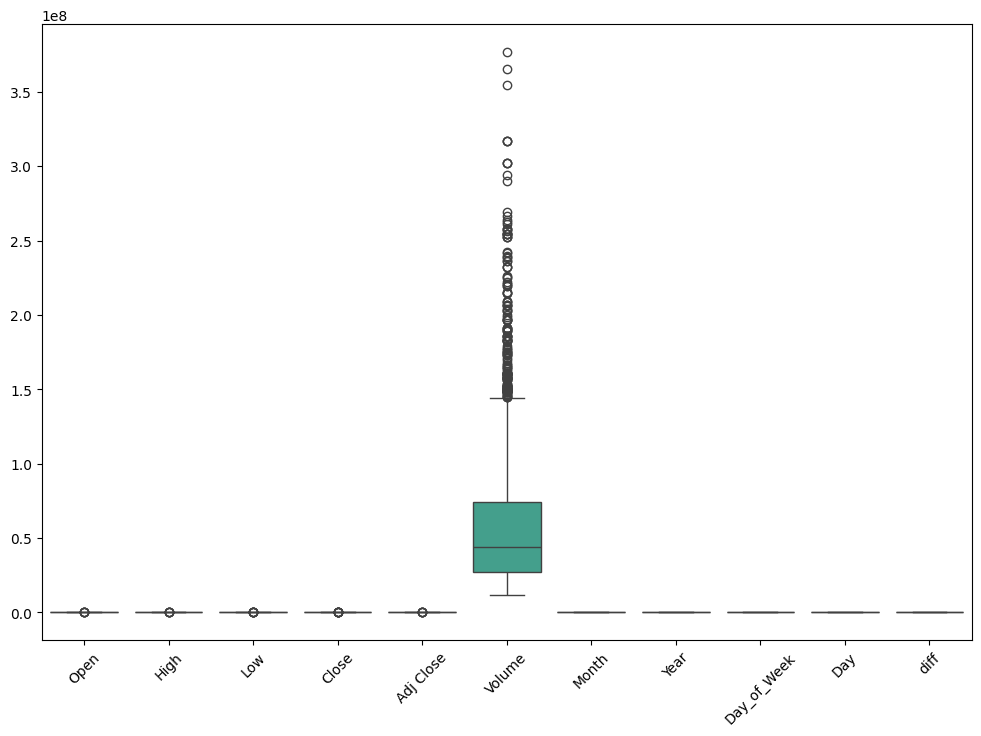

In [26]:
#Boxplot for Outlier Detection
import seaborn as sns
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

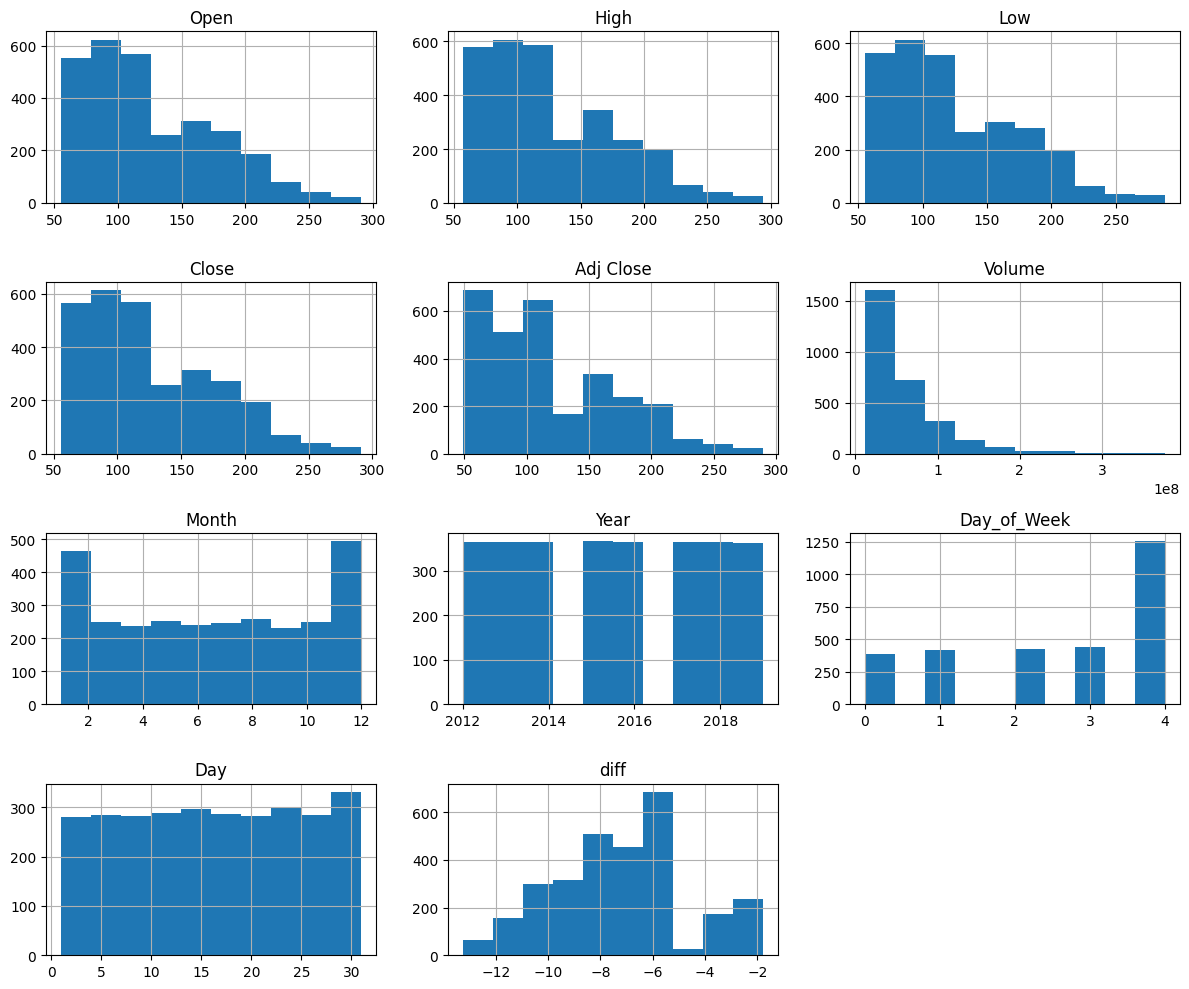

In [27]:
# Histogram
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

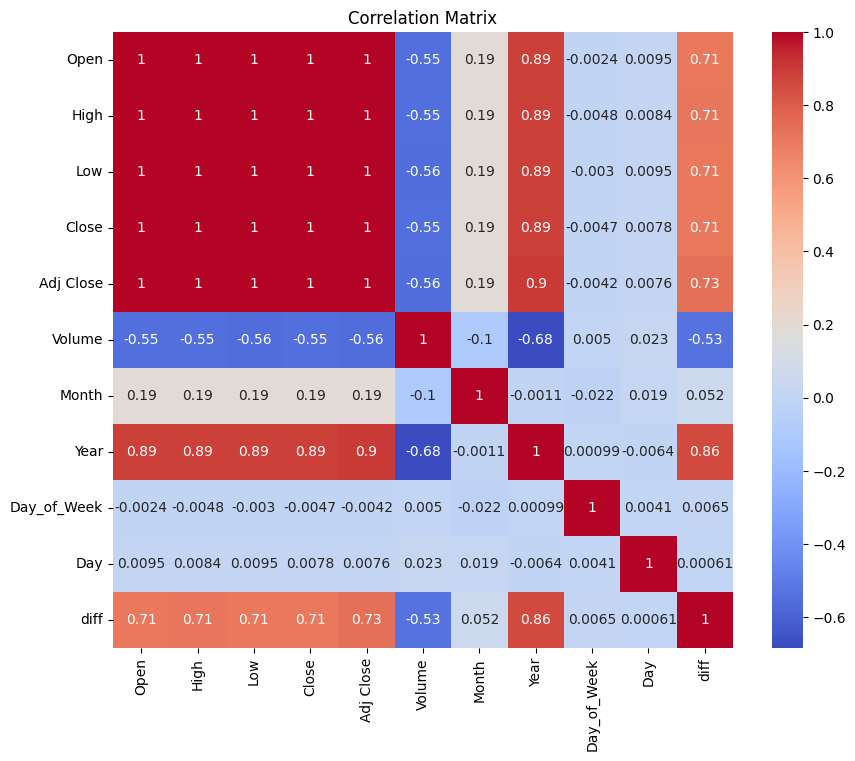

In [28]:
#Checking for Correlation MAtrix
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [29]:
'''
Time series should be stationary before analysis because most forecasting models assume that the statistical properties of the series do not
change over time.

Stationary series have constant mean and variance over time.
Models like AR, MA, ARIMA rely on historical patterns to predict the future.
If the series is non-stationary (trend, seasonality, changing variance), these models can give biased or inaccurate predictions.

The Augmented Dickey-Fuller (ADF) test is a statistical test used in time series analysis to check whether a series is stationary or not
'''
# ==========================
# 📌 Step 4: ADF Stationarity Test
# ==========================
from statsmodels.tsa.stattools import adfuller

def adf_test(series):
    result = adfuller(series)
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4]
    }

# ADF on original data
adf_result_original = adf_test(df['Adj Close'])
adf_result_original

{'ADF Statistic': np.float64(1.5056861267053803),
 'p-value': np.float64(0.9975451344848602),
 'Critical Values': {'1%': np.float64(-3.4326030422464138),
  '5%': np.float64(-2.8625354431090244),
  '10%': np.float64(-2.5672999025657584)}}

<Figure size 1200x600 with 0 Axes>

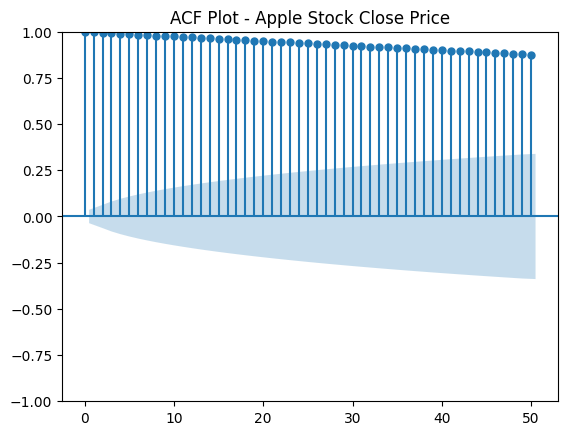

In [30]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(12,6))

plot_acf(df['Close'], lags=50)

plt.title("ACF Plot - Apple Stock Close Price")

plt.show()

<Figure size 1200x600 with 0 Axes>

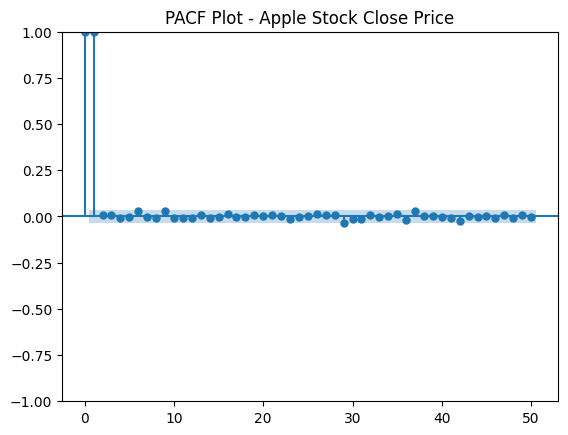

In [31]:
plt.figure(figsize=(12,6))

plot_pacf(df['Close'], lags=50)

plt.title("PACF Plot - Apple Stock Close Price")

plt.show()

Differencing

In [32]:
df['Close_diff'] = df['Close'].diff()

df.dropna(inplace=True)

In [33]:
result = adfuller(df['Close_diff'].dropna())

print("ADF Statistic:", result[0])
print("P-value:", result[1])

ADF Statistic: -13.986102852275096
P-value: 4.094782245451588e-26


ACF & PACF on Differenced Data

<Figure size 1200x600 with 0 Axes>

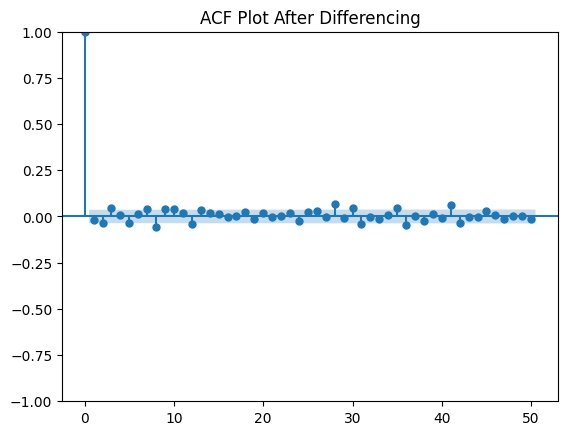

In [34]:
plt.figure(figsize=(12,6))

plot_acf(df['Close_diff'], lags=50)

plt.title("ACF Plot After Differencing")

plt.show()

<Figure size 1200x600 with 0 Axes>

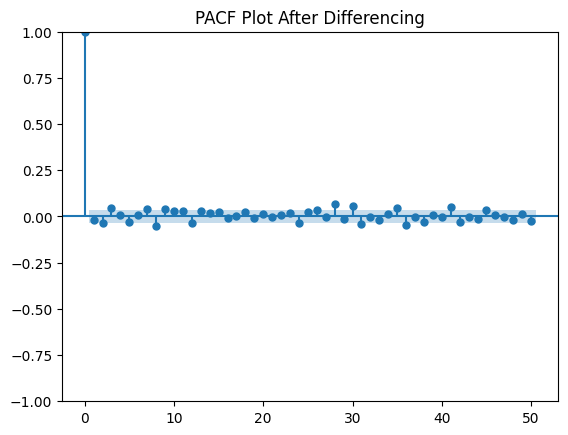

In [35]:
plt.figure(figsize=(12,6))

plot_pacf(df['Close_diff'], lags=50)

plt.title("PACF Plot After Differencing")

plt.show()

Feature Engineering

In [36]:
# Lag Feature

df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)

print(df[['Close', 'Lag_1', 'Lag_2', 'Lag_3']].head())

                Close      Lag_1      Lag_2      Lag_3
2012-01-04  59.062859        NaN        NaN        NaN
2012-01-05  59.718571  59.062859        NaN        NaN
2012-01-06  60.342857  59.718571  59.062859        NaN
2012-01-07  60.342857  60.342857  59.718571  59.062859
2012-01-08  60.342857  60.342857  60.342857  59.718571


In [37]:
# Moving average feature

df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()

print(df[['MA_5', 'MA_10', 'MA_20']].head(20))

                 MA_5      MA_10      MA_20
2012-01-04        NaN        NaN        NaN
2012-01-05        NaN        NaN        NaN
2012-01-06        NaN        NaN        NaN
2012-01-07        NaN        NaN        NaN
2012-01-08  59.962000        NaN        NaN
2012-01-09  60.198857        NaN        NaN
2012-01-10  60.347714        NaN        NaN
2012-01-11  60.352000        NaN        NaN
2012-01-12  60.323142        NaN        NaN
2012-01-13  60.249142  60.105571        NaN
2012-01-14  60.194285  60.196571        NaN
2012-01-15  60.096286  60.222000        NaN
2012-01-16  60.018000  60.185000        NaN
2012-01-17  60.112572  60.217857        NaN
2012-01-18  60.378287  60.313714        NaN
2012-01-19  60.605144  60.399715        NaN
2012-01-20  60.619144  60.357715        NaN
2012-01-21  60.633144  60.325572        NaN
2012-01-22  60.507429  60.310001        NaN
2012-01-23  60.458858  60.418572  60.262072


In [38]:
# Percentage returns

df['Daily_Return'] = df['Close'].pct_change()

# Volume percentage change
df['Volume_Change'] = df['Volume'].pct_change()

print(df[['Daily_Return', 'Volume_Change']].head())

            Daily_Return  Volume_Change
2012-01-04           NaN            NaN
2012-01-05      0.011102       0.043256
2012-01-06      0.010454       0.173345
2012-01-07      0.000000       0.000000
2012-01-08      0.000000       0.000000


In [39]:
# EMA

df['EMA_5'] = df['Close'].ewm(span=5, adjust=False).mean()
df['EMA_10'] = df['Close'].ewm(span=10, adjust=False).mean()
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

print(df[['EMA_5', 'EMA_10', 'EMA_20']].head(20))

                EMA_5     EMA_10     EMA_20
2012-01-04  59.062859  59.062859  59.062859
2012-01-05  59.281430  59.182079  59.125308
2012-01-06  59.635239  59.393130  59.241265
2012-01-07  59.871112  59.565808  59.346178
2012-01-08  60.028360  59.707089  59.441100
2012-01-09  60.101288  59.805281  59.517866
2012-01-10  60.221810  59.924840  59.607865
2012-01-11  60.269302  60.004739  59.679905
2012-01-12  60.245725  60.039981  59.729302
2012-01-13  60.154769  60.027777  59.752498
2012-01-14  60.094132  60.017792  59.773484
2012-01-15  60.053707  60.009622  59.792472
2012-01-16  60.026758  60.002938  59.809652
2012-01-17  60.241648  60.124481  59.891726
2012-01-18  60.594909  60.338472  60.025983
2012-01-19  60.765653  60.478230  60.128951
2012-01-20  60.524722  60.399072  60.120752
2012-01-21  60.364100  60.334306  60.113333
2012-01-22  60.257020  60.281315  60.106621
2012-01-23  60.524203  60.422634  60.197283


In [40]:
# Daily Returns

df['Returns'] = df['Close'].pct_change()

print(df[['Close', 'Returns']].head())


                Close   Returns
2012-01-04  59.062859       NaN
2012-01-05  59.718571  0.011102
2012-01-06  60.342857  0.010454
2012-01-07  60.342857  0.000000
2012-01-08  60.342857  0.000000


In [41]:
# Rolling Standard Devitation

df['Rstd_5'] = df['Close'].rolling(window=5).std()
df['Rstd_10'] = df['Close'].rolling(window=10).std()
df['Rstd_20'] = df['Close'].rolling(window=20).std()

print(df[['Rstd_5', 'Rstd_10', 'Rstd_20']].head(20))

              Rstd_5   Rstd_10   Rstd_20
2012-01-04       NaN       NaN       NaN
2012-01-05       NaN       NaN       NaN
2012-01-06       NaN       NaN       NaN
2012-01-07       NaN       NaN       NaN
2012-01-08  0.570716       NaN       NaN
2012-01-09  0.271668       NaN       NaN
2012-01-10  0.076555       NaN       NaN
2012-01-11  0.076815       NaN       NaN
2012-01-12  0.103556       NaN       NaN
2012-01-13  0.185625  0.427762       NaN
2012-01-14  0.223108  0.234373       NaN
2012-01-15  0.178878  0.185434       NaN
2012-01-16  0.100941  0.195291       NaN
2012-01-17  0.312410  0.245887       NaN
2012-01-18  0.598173  0.423053       NaN
2012-01-19  0.620641  0.490114       NaN
2012-01-20  0.603362  0.501954       NaN
2012-01-21  0.585154  0.511684       NaN
2012-01-22  0.639838  0.518304       NaN
2012-01-23  0.569890  0.552426  0.506964


In [42]:
# Remove null value

df.dropna(inplace=True)

df.isnull().sum()

Open             0
High             0
Low              0
Close            0
Adj Close        0
Volume           0
Month            0
Year             0
Day_of_Week      0
Day              0
diff             0
Close_diff       0
Lag_1            0
Lag_2            0
Lag_3            0
MA_5             0
MA_10            0
MA_20            0
Daily_Return     0
Volume_Change    0
EMA_5            0
EMA_10           0
EMA_20           0
Returns          0
Rstd_5           0
Rstd_10          0
Rstd_20          0
dtype: int64

In [43]:
# Split into X and Y

#Feature

X = df[['Lag_1','Lag_2','MA_5','MA_10','Daily_Return','Volume']]


# Target

y = df['Close']



In [44]:
# Data Partition

split_size = int(len(df) * 0.8)

X_train = X[:split_size]
X_test = X[split_size:]

y_train = y[:split_size]
y_test = y[split_size:]

print(X_train.shape)
print(X_test.shape)

(2319, 6)
(580, 6)


In [45]:
# Transform Data(Standardize data)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building

In [46]:
# Arima Model
import warnings
warnings.filterwarnings('ignore')
!pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
from pmdarima import auto_arima

auto_model = auto_arima(
    y_train,
    seasonal=False,
    trace=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=8056.612, Time=1.11 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=8050.456, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=8051.735, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=8051.730, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=8052.137, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=8053.280, Time=0.51 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0] intercept
Total fit time: 2.078 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2319
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -4023.228
Date:                Thu, 18 Jun 2026   AIC                           8050.456
Time:                        22:10:56   BIC                           8061.953
Sample:                    01-23-2012   HQIC                          8054.646
          

In [48]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(y_train,
                    order=(0,1,0))

arima_fit = arima_model.fit()

arima_pred = arima_fit.forecast(steps=30)

In [49]:
# Prediction

arima_pred = arima_fit.forecast(
    steps=len(y_test)
)

print(arima_pred)

2018-05-30    187.899994
2018-05-31    187.899994
2018-06-01    187.899994
2018-06-02    187.899994
2018-06-03    187.899994
                 ...    
2019-12-26    187.899994
2019-12-27    187.899994
2019-12-28    187.899994
2019-12-29    187.899994
2019-12-30    187.899994
Freq: D, Name: predicted_mean, Length: 580, dtype: float64


In [50]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae_arima = mean_absolute_error(y_test, arima_pred)

rmse_arima = np.sqrt(
    mean_squared_error(y_test, arima_pred)
)

mape_arima = np.mean(
    np.abs((y_test - arima_pred) / y_test)
) * 100

r2_arima = r2_score(y_test, arima_pred)

print("ARIMA Results")
print("MAE :", mae_arima)
print("RMSE:", rmse_arima)
print("MAPE:", mape_arima)
print("R2 Score:", r2_arima)

ARIMA Results
MAE : 26.040847703448282
RMSE: 34.752045176772064
MAPE: 11.970723919916775
R2 Score: -0.29133925572166386


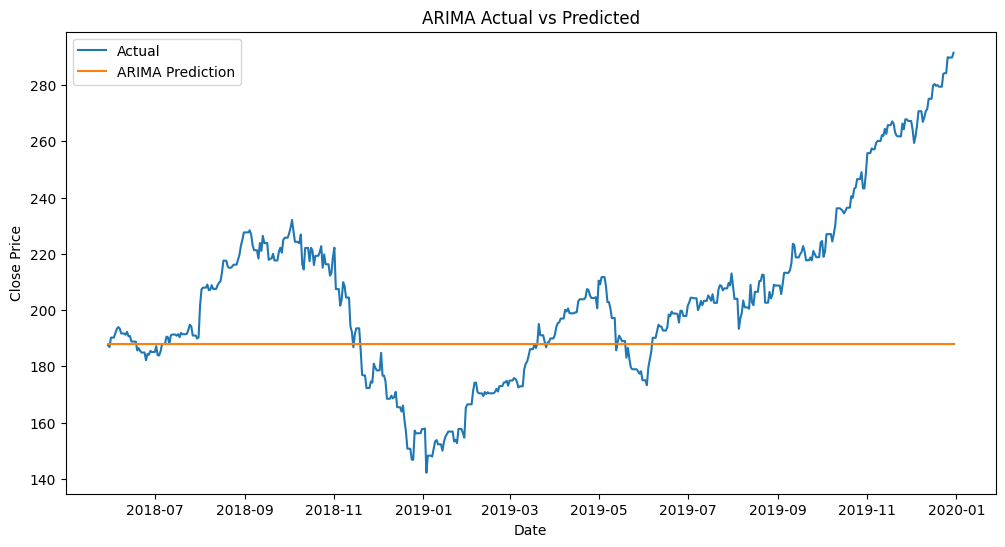

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    arima_pred,
    label='ARIMA Prediction'
)

plt.title('ARIMA Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()

plt.show()

In [52]:
from statsmodels.tsa.arima.model import ARIMA

# Train Final Model on Full Dataset
final_arima = ARIMA(
    df['Close'],
    order=(0,1,0)
)

final_fit = final_arima.fit()

In [53]:
# Forecast Next 30 Days
future_forecast = final_fit.forecast(
    steps=30
)

print(future_forecast)

2019-12-31    291.519989
2020-01-01    291.519989
2020-01-02    291.519989
2020-01-03    291.519989
2020-01-04    291.519989
2020-01-05    291.519989
2020-01-06    291.519989
2020-01-07    291.519989
2020-01-08    291.519989
2020-01-09    291.519989
2020-01-10    291.519989
2020-01-11    291.519989
2020-01-12    291.519989
2020-01-13    291.519989
2020-01-14    291.519989
2020-01-15    291.519989
2020-01-16    291.519989
2020-01-17    291.519989
2020-01-18    291.519989
2020-01-19    291.519989
2020-01-20    291.519989
2020-01-21    291.519989
2020-01-22    291.519989
2020-01-23    291.519989
2020-01-24    291.519989
2020-01-25    291.519989
2020-01-26    291.519989
2020-01-27    291.519989
2020-01-28    291.519989
2020-01-29    291.519989
Freq: D, Name: predicted_mean, dtype: float64


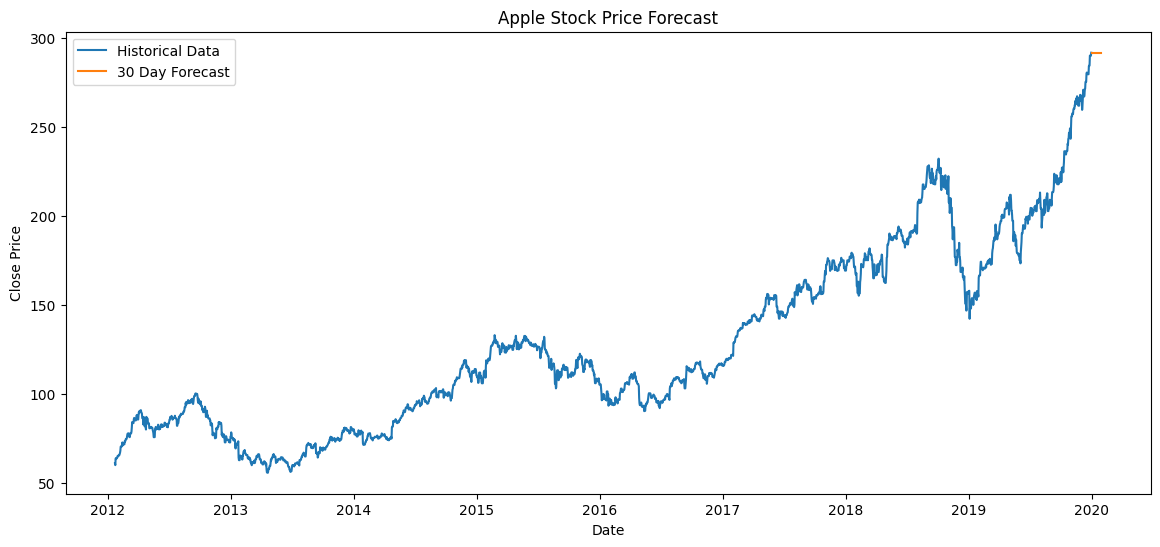

In [54]:
# Plot Future Forecast
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30
)

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Close'],
    label='Historical Data'
)

plt.plot(
    future_dates,
    future_forecast,
    label='30 Day Forecast'
)

plt.title('Apple Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()

plt.show()

In [55]:
# Sarima Model
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    y_train,
    order=(0,1,0),
    seasonal_order=(1,1,1,30),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                Close   No. Observations:                 2319
Model:             SARIMAX(0, 1, 0)x(1, 1, [1], 30)   Log Likelihood               -3988.662
Date:                              Thu, 18 Jun 2026   AIC                           7983.325
Time:                                      22:11:12   BIC                           8000.490
Sample:                                  01-23-2012   HQIC                          7989.589
                                       - 05-29-2018                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L30    6.644e-06      0.021      0.000      1.000      -0.040       0.040
ma.S.L30      -1.01

In [56]:
# Forecast Test Data
sarima_pred = sarima_fit.forecast(
    steps=len(y_test)
)

In [57]:
# Evaluate SARIMA
mae_sarima = mean_absolute_error(
    y_test,
    sarima_pred
)

rmse_sarima = np.sqrt(
    mean_squared_error(
        y_test,
        sarima_pred
    )
)

mape_sarima = np.mean(
    np.abs(
        (y_test - sarima_pred) / y_test
    )
) * 100

r2_sarima = r2_score(y_test, sarima_pred)

print("SARIMA Results")
print("MAE :", mae_sarima)
print("RMSE:", rmse_sarima)
print("MAPE:", mape_sarima)
print("R2 Score:", r2_sarima)

SARIMA Results
MAE : 21.37753944841933
RMSE: 26.877630558823643
MAPE: 10.682024508917658
R2 Score: 0.22756565195893608


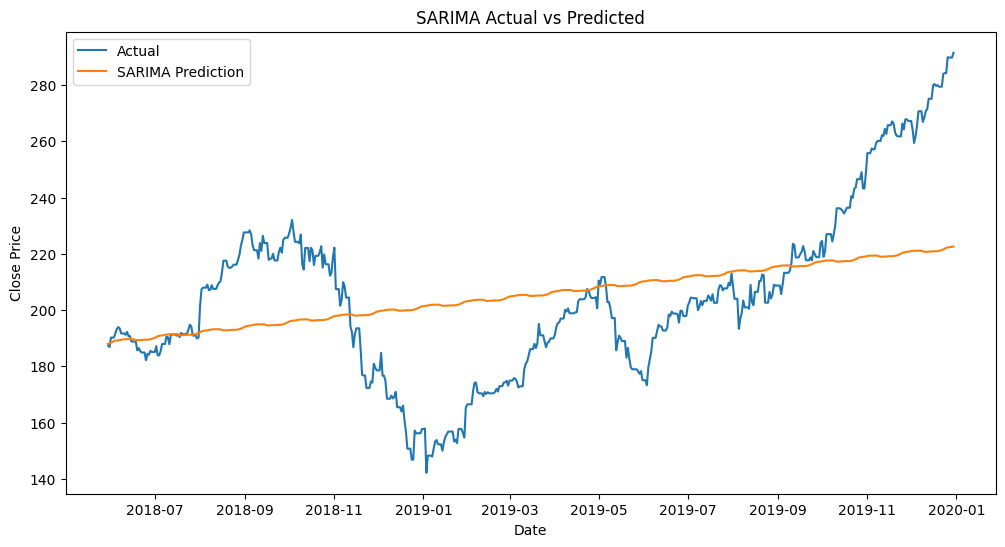

In [58]:
# Actual vs Predicted
plt.figure(figsize=(12,6))

plt.plot(
    y_test.index,
    y_test,
    label='Actual'
)

plt.plot(
    y_test.index,
    sarima_pred,
    label='SARIMA Prediction'
)

plt.title('SARIMA Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.show()

In [59]:
# Train Final SARIMA on Complete Dataset
final_sarima = SARIMAX(
    df['Close'],
    order=(0,1,0),
    seasonal_order=(1,1,1,30),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_fit = final_sarima.fit()

In [60]:
# Forecast Next 30 Days
future_sarima = final_sarima_fit.forecast(
    steps=30
)

print(future_sarima)

2019-12-31    291.839393
2020-01-01    291.729873
2020-01-02    291.410633
2020-01-03    291.643707
2020-01-04    291.807205
2020-01-05    292.372160
2020-01-06    292.258646
2020-01-07    292.306347
2020-01-08    291.785244
2020-01-09    292.145710
2020-01-10    292.415622
2020-01-11    292.190346
2020-01-12    292.573993
2020-01-13    292.384231
2020-01-14    292.400261
2020-01-15    292.651629
2020-01-16    292.810327
2020-01-17    292.564260
2020-01-18    292.657988
2020-01-19    292.652942
2020-01-20    292.799814
2020-01-21    292.973328
2020-01-22    293.567990
2020-01-23    294.086389
2020-01-24    294.384904
2020-01-25    295.000482
2020-01-26    295.170629
2020-01-27    295.412098
2020-01-28    295.073053
2020-01-29    295.208072
Freq: D, Name: predicted_mean, dtype: float64


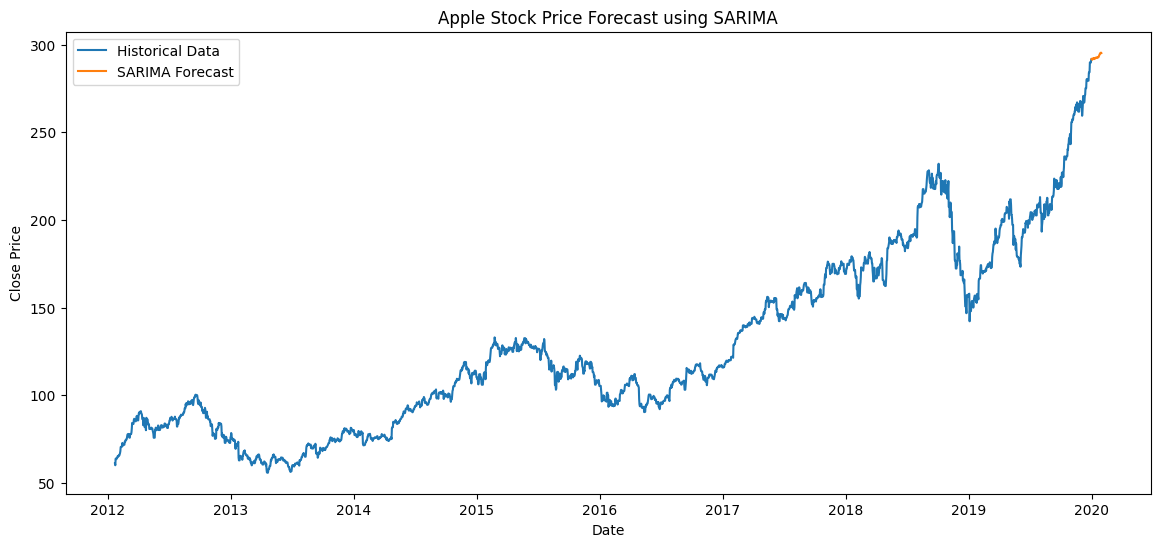

In [61]:
# Plot 30-Day Forecast
future_dates = pd.date_range(
    start=df.index[-1] + pd.Timedelta(days=1),
    periods=30
)

plt.figure(figsize=(14,6))

plt.plot(
    df.index,
    df['Close'],
    label='Historical Data'
)

plt.plot(
    future_dates,
    future_sarima,
    label='SARIMA Forecast'
)

plt.title('Apple Stock Price Forecast using SARIMA')
plt.xlabel('Date')
plt.ylabel('Close Price')

plt.legend()
plt.show()

In [62]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

# Features and Target
X = df[['Lag_1','Lag_2','MA_5','MA_10','Daily_Return','Volume']]
y = df['Close']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train Model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation Metrics
mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
r2_rf = r2_score(y_test, rf_pred)

# MAPE
mape_rf = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print("Random Forest Results")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R² Score:", r2_rf)
print("MAPE:", mape_rf, "%")

Random Forest Results
MAE : 21.603875015344833
RMSE: 32.9449398413501
R² Score: -0.16053182589704118
MAPE: 9.226353353403427 %


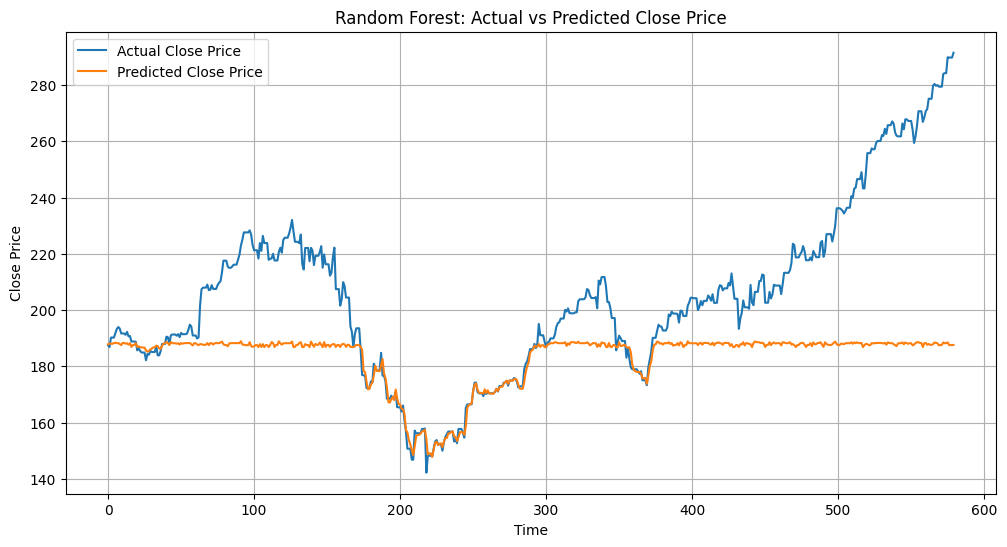

In [63]:
# Plot actual vs. Random Forest predicted values
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close Price')
plt.plot(rf_pred, label='Predicted Close Price')
plt.title('Random Forest: Actual vs Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

In [64]:
# XGBoost Model
from xgboost import XGBRegressor

# Features and Target
X = df[['Lag_1','Lag_2','MA_5','MA_10','Daily_Return','Volume']]
y = df['Close']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# XGBoost Model
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    objective='reg:squarederror',
    random_state=42
)

# Train Model
xgb_model.fit(X_train, y_train)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluation Metrics
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
r2_xgb = r2_score(y_test, xgb_pred)

# MAPE
mape_xgb = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print("XGBoost Results")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R² Score:", r2_xgb)
print("MAPE:", mape_xgb, "%")

XGBoost Results
MAE : 21.41599567047919
RMSE: 32.825064538771365
R² Score: -0.15210163897483242
MAPE: 9.129980966502343 %


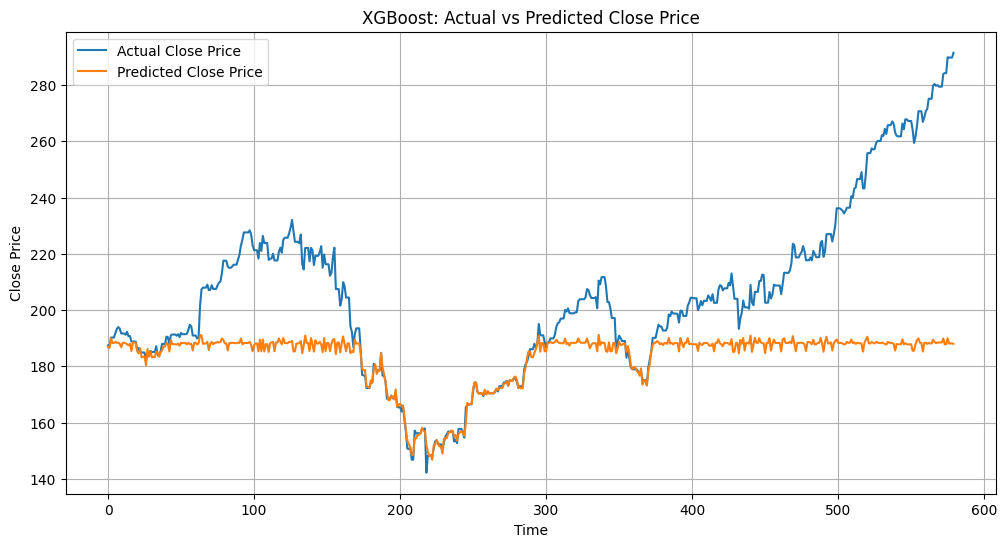

In [65]:
# Plot actual vs. XGBoost predicted values
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Close Price')
plt.plot(xgb_pred, label='Predicted Close Price')
plt.title('XGBoost: Actual vs Predicted Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.show()

# Model comparison

In [66]:
comparison = pd.DataFrame({
    'Model':['ARIMA','SARIMA','Random Forest','XGBoost'],
    'MAE':[mae_arima,mae_sarima,mae_rf,mae_xgb],
    'RMSE':[rmse_arima,rmse_sarima,rmse_rf,rmse_xgb],
    'MAPE':[mape_arima,mape_sarima,mape_rf,mape_xgb],
    'R2':[r2_arima,r2_sarima,r2_rf,r2_xgb]
})

comparison

,Model,MAE,RMSE,MAPE,R2
0,ARIMA,26.040848,34.752045,11.970724,-0.291339
1,SARIMA,21.377539,26.877631,10.682025,0.227566
2,Random Forest,21.603875,32.944940,9.226353,-0.160532
3,XGBoost,21.415996,32.825065,9.129981,-0.152102


### Final Model Selection for Deployment

After evaluating ARIMA, SARIMA, Random Forest, and XGBoost using MAE, RMSE, MAPE, and R² Score, SARIMA was selected as the final model for deployment. SARIMA achieved the lowest MAE (21.38) and RMSE (26.88), indicating the smallest prediction errors among all models. It also obtained the highest R² score (0.228), showing better predictive performance compared to the other models. Since SARIMA provided the most accurate and reliable forecasts for Apple stock prices, it was chosen as the final deployment model.


In [67]:
import joblib
joblib.dump(final_sarima ,"final_sarima_model.pkl")


['final_sarima_model.pkl']

In [68]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

## After coverting models into pkl file we can go to deploy